# Phase 1: Data Acquisition & Exploratory Data Analysis (EDA)

**Goal:** Turn raw, messy transactional data into a clean, reliable baseline for customer-behavior analysis (RFM, churn, and LTV modeling in later phases).

**Dataset:** [Online Retail Dataset](https://www.kaggle.com/datasets/vijayuv/onlineretail) — real transactions from a UK-based non-store online retailer, Dec 2010–Dec 2011.

This notebook covers:
1. Data acquisition & first look
2. Data quality audit (missing values, duplicates)
3. Data cleaning (cancellations, missing IDs, invalid values, outliers, non-product entries)
4. Feature engineering
5. Cohort retention analysis

> ⚠️ **Run this notebook top-to-bottom** (`Kernel → Restart & Run All`)

## Step 1: Dataset Acquisition

In [ ]:
# 1. Install the library
!pip install opendatasets

import opendatasets as od

# 2. Provide the direct Kaggle dataset link
dataset_link = "https://www.kaggle.com/datasets/vijayuv/onlineretail"

# 3. Run the download
# (Get these from https://www.kaggle.com/settings -> API -> Create New Token)
od.download(dataset_link)


  Using cached opendatasets-0.1.22-py3-none-any.whl.metadata (9.2 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
Using cached opendatasets-0.1.22-py3-none-any.whl (15 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)
Using cached markdown_it_py-4.2.0-py3-none-any.whl (91 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached idna-3.18-py3-none-any.whl (65 kB)
Using cached certifi-2026.7.22-py3-none-any.whl (136 kB)

   -- ------------------------

## Step 2: Initial Load & Overview

Load the raw CSV and get a first look at shape, dtypes, and summary statistics *before* touching anything. This is the baseline every later cleaning step gets compared against.

In [4]:
import pandas as pd
import numpy as np


df = pd.read_csv(
    r'..\data\raw\onlineretail.csv',
    encoding='cp1252'
)

# Capture the raw row count now — used later in the cleaning funnel summary,
# so we don't have to hardcode a number that goes stale if the source file changes.
raw_row_count = df.shape[0]

print("========== FIRST 5 ROWS ==========")
display(df.head()) # 'display()' renders beautiful tables in Jupyter

print("\n========== DATASET SHAPE ==========")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

print("\n========== DATASET INFO ==========")
df.info()

print("\n========== NUMERICAL SUMMARY ==========")
display(df.describe())


========== FIRST 5 ROWS ==========


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



========== DATASET SHAPE ==========
Rows: 541909 | Columns: 8

========== DATASET INFO ==========
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB

========== NUMERICAL SUMMARY ==========


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Step 3: Data Quality Audit

Before cleaning, quantify what's actually wrong with the data: missing values and duplicate rows.

### 3.1 Missing Values

In [5]:
print(f"Initial Dataset Shape: {df.shape}")
print(df.isnull().sum())


Initial Dataset Shape: (541909, 8)
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### 3.2 Duplicate Rows

The Online Retail dataset is known to contain exact duplicate transaction rows (the same invoice line logged twice). These aren't real repeat behavior — they're double-counted transactions that will quietly inflate revenue, frequency, and quantity metrics in Phase 2 (RFM) if left in. Check and remove them now, before any other cleaning.

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows found: {duplicate_count} ({duplicate_count / len(df):.2%} of dataset)")

df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


Exact duplicate rows found: 5268 (0.97% of dataset)
Shape after removing duplicates: (536641, 8)


## Step 4: Data Cleaning

### 4.1 Handle Cancelled Orders

Invoices starting with `'C'` are cancellations — they represent returns, not purchases, so we separate them out rather than treating them as regular transactions. `df_cancelled` is kept around in case you want to analyze return behavior separately later (e.g., which products get returned most).

In [7]:
is_cancelled = df['InvoiceNo'].str.startswith('C', na=False)

# Separate cancellations for advanced analysis later, or drop them for the baseline model
df_cancelled = df[is_cancelled]
df = df[~is_cancelled]

print(f"Removed {df_cancelled.shape[0]} cancelled transactions.")


Removed 9251 cancelled transactions.


### 4.2 Handle Missing CustomerID

Transactions without a `CustomerID` can't be tied to a specific customer, so they're unusable for any customer-level analysis (RFM, churn, LTV). Before dropping them, we quantify how much revenue they represent — if it's a meaningful chunk, that's worth flagging to stakeholders as revenue that's currently invisible to customer-level modeling.


In [8]:
missing_id_revenue = (df[df['CustomerID'].isnull()]['Quantity'] * df[df['CustomerID'].isnull()]['UnitPrice']).sum()
print(f"Revenue from missing CustomerIDs: ${missing_id_revenue:,.2f}")

df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int).astype(str) # Normalize as string ID
print(f"Shape after removing missing CustomerIDs: {df.shape}")


Revenue from missing CustomerIDs: $1,732,777.79
Shape after removing missing CustomerIDs: (392732, 8)


### 4.3 Remove Invalid Quantity / Price Rows

A small number of rows have `Quantity` or `UnitPrice` ≤ 0 that aren't tagged as cancellations (data-entry errors, adjustments, etc.). These aren't caught by the `'C'`-invoice-prefix rule above, so we filter them explicitly.

In [9]:
# Ensure UnitPrice and Quantity are strictly positive numbers
invalid_rows = df[(df['Quantity'] <= 0) | (df['UnitPrice'] <= 0)]
print(f"Removing {invalid_rows.shape[0]} rows with zero or negative values.")

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]


Removing 40 rows with zero or negative values.


### 4.4 Outlier Removal — Quantity *and* Unit Price

An earlier draft of this notebook only trimmed extreme **Quantity** values. But **UnitPrice** had the exact same problem — after cleaning, the maximum `UnitPrice` was still 8,142.75, which is not a normal consumer purchase and would badly distort Monetary values in Phase 2 (RFM) and the LTV models in Phase 4. Both need the same treatment.

Before blindly trimming, it's worth checking *why* these rows are extreme — legitimate wholesale/bulk orders are still valid signal, while data errors or non-product entries are not. A quick way to check: if extreme-quantity rows are spread across many countries/customers with no other pattern, that looks like real bulk buying; if they cluster around a handful of non-product `StockCode`s (postage, fees, manual adjustments), they're not purchases at all — that's handled separately in Step 4.5.

In [10]:
# Check the 99.9th percentile threshold for both Quantity and UnitPrice
print("99.9th percentile thresholds:")
print(df[['Quantity', 'UnitPrice']].quantile(0.999))

# Sanity check: do extreme-quantity orders look like real bulk/wholesale behavior,
# i.e. spread across many countries/customers rather than one anomalous source?
extreme_qty = df[df['Quantity'] >= df['Quantity'].quantile(0.999)]
print(f"\nExtreme-quantity rows ({len(extreme_qty)}) by country:")
print(extreme_qty['Country'].value_counts().head())

# Trim top 0.1% of Quantity
before = df.shape[0]
df = df[df['Quantity'] < df['Quantity'].quantile(0.999)]
print(f"\nRemoved {before - df.shape[0]} rows for extreme Quantity.")

# Trim top 0.1% of UnitPrice — this step was missing before, and is the reason
# UnitPrice max was still 8,142.75 after the original cleaning pass.
before = df.shape[0]
df = df[df['UnitPrice'] < df['UnitPrice'].quantile(0.999)]
print(f"Removed {before - df.shape[0]} rows for extreme UnitPrice.")


99.9th percentile thresholds:
Quantity     504.00
UnitPrice     49.95
Name: 0.999, dtype: float64

Extreme-quantity rows (406) by country:
Country
United Kingdom    355
Japan              12
Sweden             11
Netherlands        11
Australia          10
Name: count, dtype: int64

Removed 406 rows for extreme Quantity.
Removed 395 rows for extreme UnitPrice.


### 4.5 (Optional) Remove Non-Product / Administrative Entries

This dataset includes a handful of `StockCode`s that aren't real products — postage, bank charges, manual adjustments, and similar administrative entries. Whether to exclude these is a judgment call:

- **Exclude them** if you want RFM/LTV to reflect pure product-purchasing behavior (the common choice, and what we do below).
- **Keep them** if you consider postage/fees a legitimate part of what a customer pays the business.
- 

In [12]:
non_product_codes = ['POST', 'D', 'DOT', 'M', 'm', 'BANK CHARGES', 'PADS', 'CRUK', 'AMAZONFEE', 'S']

non_product_mask = df['StockCode'].isin(non_product_codes)
print(f"Non-product rows found: {non_product_mask.sum()}")
print(df[non_product_mask]['StockCode'].value_counts())

before = df.shape[0]
df = df[~non_product_mask]
print(f"\nRemoved {before - df.shape[0]} non-product rows. Shape: {df.shape}")


Non-product rows found: 0
Series([], Name: count, dtype: int64)

Removed 0 non-product rows. Shape: (390565, 8)


## Step 5: Feature Engineering

In [13]:
# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalRevenue metric
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']

print("\n--- Final Cleaned Data Snapshot ---")
print(f"Cleaned Dataset Shape: {df.shape}")
df.head()



--- Final Cleaned Data Snapshot ---
Cleaned Dataset Shape: (390565, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Step 6: Final Cleaned Data Validation

In [14]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,TotalRevenue
count,390565.000000,390565,390565.000000,390565.000000
mean,11.818366,2011-07-10 20:37:39.891285,2.818024,20.562320
min,1.000000,2010-12-01 08:26:00,0.040000,0.060000
25%,2.000000,2011-04-07 11:29:00,1.250000,4.950000
50%,6.000000,2011-07-31 12:34:00,1.950000,11.900000
75%,12.000000,2011-10-20 13:06:00,3.750000,19.800000
max,500.000000,2011-12-09 12:50:00,42.950000,3285.000000
std,25.824051,NaN,2.892896,53.069139


In [15]:
df.info()


<class 'pandas.DataFrame'>
Index: 390565 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     390565 non-null  str           
 1   StockCode     390565 non-null  str           
 2   Description   390565 non-null  str           
 3   Quantity      390565 non-null  int64         
 4   InvoiceDate   390565 non-null  datetime64[us]
 5   UnitPrice     390565 non-null  float64       
 6   CustomerID    390565 non-null  str           
 7   Country       390565 non-null  str           
 8   TotalRevenue  390565 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(5)
memory usage: 50.9 MB


## Step 7: Cleaning Funnel Summary

A quick recap of what was removed and why. This is also the kind of number a Product/Business stakeholder will actually ask about in a walkthrough — "how much of the raw data did we throw away, and what for?" — so it's worth having ready.

In [16]:
final_rows = df.shape[0]

print("===== CLEANING FUNNEL SUMMARY =====")
print(f"Raw rows:                 {raw_row_count:,}")
print(f"Final cleaned rows:       {final_rows:,}")
print(f"Rows removed:             {raw_row_count - final_rows:,} ({(raw_row_count - final_rows) / raw_row_count:.1%})")
print(f"Unique customers:         {df['CustomerID'].nunique():,}")
print(f"Date range:               {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Total revenue (cleaned):  ${df['TotalRevenue'].sum():,.2f}")


===== CLEANING FUNNEL SUMMARY =====
Raw rows:                 541,909
Final cleaned rows:       390,565
Rows removed:             151,344 (27.9%)
Unique customers:         4,317
Date range:               2010-12-01 to 2011-12-09
Total revenue (cleaned):  $8,030,922.53


## Phase 1B: Cohort Retention Analysis

**Goal:** Group customers by the month of their first purchase and track what percentage return in each subsequent month. The output — a retention heatmap — is one of the most useful artifacts in this whole project for a Product Manager audience: it shows exactly when users drop off in the customer lifecycle.

### Step 1: Assign Cohort Month

Every customer's cohort is the calendar month of their *first* purchase.

In [ ]:
%pip install seaborn

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a period column for the transaction month (YYYY-MM format)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# 2. Find the baseline cohort month (the very first purchase month) for each customer
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

df[['CustomerID', 'InvoiceMonth', 'CohortMonth']].head()


SyntaxError: invalid syntax (1485354491.py, line 1)

### Step 2: Calculate Cohort Index

The Cohort Index is "months since first purchase" (1 = the customer's first month, 2 = one month later, etc.) — this is what lets us line up cohorts from different starting months on the same axis.

In [ ]:
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

# Extract year and month integers
invoice_year, invoice_month = get_date_int(df, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')

# Calculate the difference in years and months
years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

# Calculate the Cohort Index (Add 1 so the first month is indexed as 1 instead of 0)
df['CohortIndex'] = years_diff * 12 + months_diff + 1


### Step 3: Build the Retention Matrix

In [ ]:
# Group by CohortMonth and CohortIndex to count unique customers
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

# Pivot the data into a matrix
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

print("Raw Customer Counts Matrix:")
print(cohort_counts.iloc[:5, :5])  # Previewing a small slice


Raw Customer Counts Matrix:
CohortIndex      1      2      3      4      5
CohortMonth                                   
2010-12      878.0  320.0  283.0  336.0  320.0
2011-01      410.0   92.0  112.0   94.0  131.0
2011-02      378.0   71.0   71.0  108.0  102.0
2011-03      451.0   67.0  113.0   90.0  101.0
2011-04      300.0   63.0   61.0   63.0   59.0


In [ ]:
# Extract the initial cohort size (the total number of users in Month 1)
cohort_sizes = cohort_counts.iloc[:, 0]

# Divide every column by the initial cohort size to get percentages
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Format as percentages for cleaner viewing (display only — `retention` itself
# stays as a 0-1 fraction, which is what the heatmap below expects)
retention.round(3) * 100


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,36.4,32.2,38.3,36.4,39.9,36.3,34.9,35.2,39.4,37.5,50.3,26.7
2011-01,100.0,22.4,27.3,22.9,32.0,29.0,25.4,24.4,30.2,33.2,37.1,11.7,NaN
2011-02,100.0,18.8,18.8,28.6,27.0,24.1,25.7,27.2,24.6,30.4,6.9,NaN,NaN
2011-03,100.0,14.9,25.1,20.0,22.4,16.6,26.4,23.1,27.7,8.4,NaN,NaN,NaN
2011-04,100.0,21.0,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05,100.0,19.6,17.4,17.8,21.0,23.1,26.7,9.3,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.4,15.7,26.4,22.3,32.6,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,17.6,20.2,22.3,26.6,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,19.4,24.7,24.1,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 4: Visualize Retention Heatmap

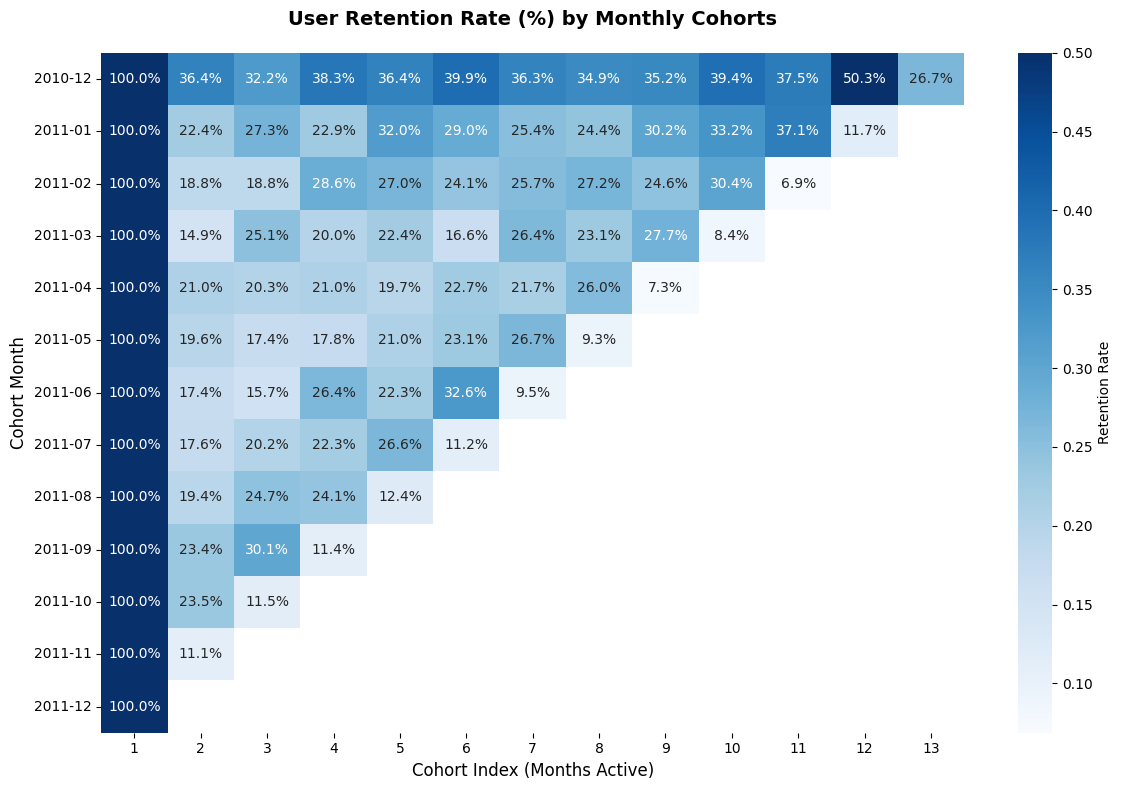

In [ ]:
plt.figure(figsize=(12, 8))
plt.title('User Retention Rate (%) by Monthly Cohorts', fontsize=14, fontweight='bold', pad=20)

sns.heatmap(
    data=retention, 
    annot=True, 
    fmt='.1%', 
    cmap='Blues', 
    vmax=0.5,  # Caps the color intensity to make subtle differences visible (since Month 1 is always 100%)
    cbar_kws={'label': 'Retention Rate'}
)

plt.ylabel('Cohort Month', fontsize=12)
plt.xlabel('Cohort Index (Months Active)', fontsize=12)
plt.tight_layout()
plt.show()


## Summary & Next Steps

**What this notebook establishes:**
- A cleaned, deduplicated, outlier-trimmed transaction dataset ready for customer-level analysis
- A monthly cohort retention matrix and heatmap showing how customer retention decays over time

In [ ]:
# At the very end of Notebook 1 (Requires 'pyarrow' or 'fastparquet' library installed):
df.to_parquet('cleaned_online_retail.parquet', index=False)

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalRevenue,InvoiceMonth,CohortMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010-12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010-12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,1


In [ ]:
retention_export = retention.copy()
retention_export.index = retention_export.index.astype(str)  # Period type doesn't serialize cleanly
retention_export.to_parquet('../data/processed/retention_matrix.parquet')

C:\Users\HP\projects
